# PJM Wind Forecast — Hybrid SNN-ANN

An evaluation of GRU, SNN, and Hybrid architectures on PJM wind data.

In [1]:
import os, sys, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from pjm_dataset import load_pjm_splits, FEATURE_COLS

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Running on {DEVICE}')

WINDOW_SIZE = 24
HORIZON = 1
BATCH_SIZE = 32
EPOCHS = 40
DATA_PATH = '../datasets/pjm_wind_forecast_hourly_17feb_5march.csv'
MODELS_DIR = '../../models'
os.makedirs(MODELS_DIR, exist_ok=True)


Running on mps


In [2]:
train_ds, val_ds, test_ds, normaliser = load_pjm_splits(
    DATA_PATH, window_size=WINDOW_SIZE, horizon=HORIZON, train_frac=0.7, val_frac=0.15
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

N_FEATURES = len(FEATURE_COLS)
print(f'Loaded {len(train_ds)} train, {len(val_ds)} val, {len(test_ds)} test.')


Loaded 194 train, 23 val, 23 test.


## Final Model Architectures

Three models for time-series forecasting, designed for head-to-head comparison:

1. **GRUForecaster** (Baseline) — Gated Recurrent Unit --> Pure ANN.
2. **SNNForecaster** (Spiking) — Pure SNN with Raw+Delta input and Deep LIF.
3. **HybridForecaster** (Combined) — Residual gating of SNN events into GRU.

**Justification for the SNNForecaster's Architecture**
1. **Raw + Delta Input**: SNNs naturally detect changes, but regression  requires absolute context. We concatenate Raw(t) and Delta(t) so the SNN can see both the absolute power level and the temporal shock.
2. **Deep LIF Capacity**: 2 layers of 256 hidden units provide the necessary capacity (approx 20k params) to represent complex continuous values, which simple rate-encoders struggle with. Before this notebook, we did experiment with versions with way fewer parameters and performance was not ideal. 
3. **BatchNorm**: Applied over the time dimension. Time-series data often causes vanishing/exploding surrogate gradients. BN ensures stable, active spiking (neurons aren't 'dead') from epoch 1.

**Justification for the Residual SNN-Enhanced-GRU Hybrid Forecaster's Architecture**
1. Parallel hybrids risk the SNN path "poisoning" the robust ANN baseline if the surrogate gradients fail to align.  So this model uses a **Residual Design**:
    - The baseline path is a standard GRU processing raw inputs.
    - The enhancement path is an SNN that *only* processes temporal deltas (acting as a pure neuromorphic shock/event detector).
    - The SNN features are added to the GRU features via a gate that is **zero-initialized**.
    - **V4 Membrane Readout**: For continuous regression, the final layer reads
       out membrane voltage instead of discrete binary spikes.
      
    Result: SNN works now. 

In [3]:
from __future__ import annotations

import torch
import torch.nn as nn


import snntorch as snn # NEW V4 SNNTorch Imports!
from snntorch import surrogate


class TemporalAttention(nn.Module):
    """
    Learned weighted sum over the time dimension.
    Input: (T, B, C) or (B, T, C) -> Output: (B, C)
    """
    def __init__(self, dim: int):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.ReLU(),
            nn.Linear(dim // 2, 1)
        )

    def forward(self, x: torch.Tensor, dim: int = 1) -> torch.Tensor:
        weights = torch.softmax(self.attn(x), dim=dim)
        return (weights * x).sum(dim=dim)


class GRUForecaster(nn.Module):
    """
    Two-layer GRU followed by a linear head.
    A strong, stable baseline for univariate/low-dimensional time-series.
    """
    def __init__(self, input_size: int, horizon: int, hidden: int = 128, n_layers: int = 2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden, num_layers=n_layers, batch_first=True)
        self.head = nn.Linear(hidden, horizon)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, h_n = self.gru(x)
        return self.head(h_n[-1])


# ═══════════════════════════════════════════════════════════════════════
#  2. PURE SNN
# ═══════════════════════════════════════════════════════════════════════

class SNNForecaster(nn.Module):
    """
    Spiking Neural Network for Time-Series Forecasting.
    
    Architectural Justification:
    ----------------------------
    1. **Raw + Delta Input**: SNNs naturally detect *changes*, but regression 
       requires absolute context. We concatenate Raw(t) and Delta(t) so the SNN 
       can see both the absolute power level and the temporal shock.
    2. **Deep LIF Capacity**: 2 layers of 256 hidden units provide the necessary
       capacity (approx 20k params) to represent complex continuous values,
       which simple rate-encoders struggle with.
    3. **BatchNorm**: Applied over the time dimension. Time-series data often
       causes vanishing/exploding surrogate gradients. BN ensures stable, 
       active spiking (neurons aren't 'dead') from epoch 1.
    4. 
    """
    def __init__(self, input_size: int, horizon: int, hidden: int = 256):
        super().__init__()
        import snntorch as snn
        from snntorch import surrogate #ATan surrogate gradient
        
        # Concat input_size + input_size (raw + delta)
        self.proj = nn.Linear(input_size * 2, hidden) # input_size*2 because model later concatenates raw values and delta values
        self.bn = nn.BatchNorm1d(hidden)
        
        spike_grad = surrogate.fast_sigmoid(slope=25)
        self.lif1 = snn.Leaky(beta=0.9, spike_grad=spike_grad, init_hidden=True) #creates the first LIF neuron layer
        self.lif2 = snn.Leaky(beta=0.9, spike_grad=spike_grad, init_hidden=True) #second LIF neuron stacked on top of first
        
        
        self.lif3 = snn.Leaky(beta=0.9, spike_grad=spike_grad, init_hidden=True, output=True) # V4 Continuous Readout Layer
        
        self.attn = TemporalAttention(hidden) #learns which timesteps are most important in the spike sequence
        self.head = nn.Linear(hidden, horizon) #final linear layer converting the learned represenation into forecast ouputs
        
        nn.init.constant_(self.proj.bias, 0.5) # Encourage initial spiking during early training

    def forward(self, x: torch.Tensor) -> torch.Tensor: #x represents a time-series batch
        import snntorch as snn
        from snntorch import utils
        utils.reset(self) #resets membrane potentials of all spiking neurons or else the next batch starts with leftover voltage
        # from the previous batch which causes info leakage between samples.
        
        delta = x[:, 1:, :] - x[:, :-1, :] #computes changes between consecutive timesteps. x : (B, T, F)
        raw = x[:, 1:, :] #removes first timestep. raw and delta have the same length because the first timestep has no value and it cannot produce a delta.
        combined = torch.cat([raw, delta], dim=-1) # (B, T-1, F*2) --> feat dimension doubles and now each timestep contains [value , change]
        
        h = self.proj(combined) #projects features into hidden dimension wich is standard for neural feature dimension
        h = self.bn(h.transpose(1, 2)).transpose(1, 2)
        
        h_t = h.permute(1, 0, 2)
        
        mem_rec = []
        for step in range(h_t.size(0)):
            s1 = self.lif1(h_t[step]) #integrates input, fires spike if threshold crossed, leaks voltage over time
            s2 = self.lif2(s1) #processes spikes again to learn higher-level temporal spike patterns
            _, mem3 = self.lif3(s2) # V4: Read membrane continuous voltage for regression
            mem_rec.append(mem3)
            
        mem_rec = torch.stack(mem_rec, dim=0) # (T, B, hidden)
        
        feat = self.attn(mem_rec.permute(1, 0, 2)) #attention learns which timesteps matter most AFTER converting back to batch format
        return self.head(feat) #Linear layer maps representation to (B, horizon) --> E.g. predict next 6 timesteps for that batch size

    def spike_count(self, x: torch.Tensor) -> int:
        import snntorch as snn
        from snntorch import utils
        utils.reset(self)
        with torch.no_grad():
            delta = x[:, 1:, :] - x[:, :-1, :]
            raw = x[:, 1:, :]
            combined = torch.cat([raw, delta], dim=-1)
            h = self.proj(combined)
            h = self.bn(h.transpose(1, 2)).transpose(1, 2)
            h_t = h.permute(1, 0, 2)
            
            total_spikes = 0
            for step in range(h_t.size(0)):
                s1 = self.lif1(h_t[step])
                s2 = self.lif2(s1)
                total_spikes += int(s1.sum().item() + s2.sum().item())
            return total_spikes #aft running through LIF layers, count spikes emitted by each layer


class HybridForecaster(nn.Module):
    def __init__(self, input_size: int, horizon: int, hidden: int = 128):
        super().__init__()
        import snntorch as snn
        from snntorch import surrogate
        
        self.gru = nn.GRU(input_size, hidden, batch_first=True)  # Baseline Path (GRU on Raw)
        self.gru_attn = TemporalAttention(hidden) #applies attention across time to extract a single sequence representation
        
        self.snn_dim = 128 # hidden dimension for SNN and this defines spike feature dimension
        self.snn_proj = nn.Linear(input_size, self.snn_dim) #projects delta features into the spike feature space
        
        spike_grad = surrogate.fast_sigmoid(slope=25)
        self.snn_lif = snn.Leaky(beta=0.9, spike_grad=spike_grad, init_hidden=True, output=True) #LIF neuron integrates signal and emits spikes when threshold crossed
        
        self.snn_attn = TemporalAttention(self.snn_dim) #Learns which spike moments matter most
        self.snn_to_gru = nn.Linear(self.snn_dim, hidden) #needed for both paths to share the same dimension
        
        self.gate_proj = nn.Linear(hidden + self.snn_dim, 1) #creates a gating signal controlling how much SNN information to use
        nn.init.constant_(self.gate_proj.weight, 0)
        nn.init.constant_(self.gate_proj.bias, -5.0) # Sigmoid starts near 0 at the start of training and SNN contribution gradually grows during training
        
        self.head = nn.Linear(hidden, horizon)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        import snntorch as snn
        from snntorch import utils
        utils.reset(self)
        
        
        gru_out, _ = self.gru(x) # Baseline Path
        h_ann = self.gru_attn(gru_out)
        
        # Enhancement Path (Delta only)
        delta = x[:, 1:, :] - x[:, :-1, :]
        h_s = self.snn_proj(delta)
        h_s_t = h_s.permute(1, 0, 2)
        
        mem_rec = []
        for step in range(h_s_t.size(0)):
            _, mem = self.snn_lif(h_s_t[step])
            mem_rec.append(mem)
        mem_rec = torch.stack(mem_rec, dim=0)
        
        h_snn = self.snn_attn(mem_rec.permute(1, 0, 2))
        
        
        g = torch.sigmoid(self.gate_proj(torch.cat([h_ann, h_snn], dim=-1))) #signmoid determines if we use SNN or ignore fully. 0 is ignore and 1 is fully use.
        h_combined = h_ann + g * self.snn_to_gru(h_snn) #residual fusion
        
        return self.head(h_combined)

    def spike_count(self, x: torch.Tensor) -> int:
        import snntorch as snn
        from snntorch import utils
        utils.reset(self)
        with torch.no_grad():
            delta = x[:, 1:, :] - x[:, :-1, :]
            h_s = self.snn_proj(delta)
            h_s_t = h_s.permute(1, 0, 2)
            
            total_spikes = 0
            self.snn_lif.output = False
            for step in range(h_s_t.size(0)):
                spk = self.snn_lif(h_s_t[step])
                total_spikes += int(spk.sum().item())
            self.snn_lif.output = True
            
            return total_spikes


## Defining utilities functions

In [4]:
def evaluate_model(model, loader, normaliser, device):
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            p = normaliser.inverse_transform_target(out.cpu().numpy(), target_idx=0)
            a = normaliser.inverse_transform_target(y.cpu().numpy(), target_idx=0)
            preds.extend(p)
            actuals.extend(a)
    
    preds = np.array(preds).flatten()
    actuals = np.array(actuals).flatten()
    
    mae = np.mean(np.abs(preds - actuals))
    rmse = np.sqrt(np.mean((preds - actuals)**2))
    mape = np.mean(np.abs((actuals - preds) / (actuals + 1e-8))) * 100
    return mae, rmse, mape, preds, actuals

def train_model(model, train_loader, val_loader, name, lr=1e-3, epochs=EPOCHS, patience=10):
    model.to(DEVICE)
    criterion = nn.MSELoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_epoch = 0
    patience_counter = 0
    start_time = time.time()
    
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimiser.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            train_loss += loss.item() * x.size(0)
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = model(x)
                val_loss += criterion(out, y).item() * x.size(0)
        
        avg_train = train_loss / len(train_loader.dataset)
        avg_val = val_loss / len(val_loader.dataset)
        
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_epoch = epoch
            patience_counter = 0
            ckpt_path = os.path.join(MODELS_DIR, f'best_{name}.pt')
            torch.save(model.state_dict(), ckpt_path)
            # print(f"[{name}] Best Val Epoch {epoch}: {best_val_loss:.6f}")
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            break
            
    train_time = time.time() - start_time
    history['train_time'] = train_time
    history['best_epoch'] = best_epoch
    
    ckpt_path = os.path.join(MODELS_DIR, f'best_{name}.pt')
    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
    return history


## Model Training 

In [5]:
models = {
    'GRU (Baseline)': GRUForecaster(N_FEATURES, HORIZON),
    'SNN (Raw+Delta)': SNNForecaster(N_FEATURES, HORIZON),
    'Hybrid (Residual)': HybridForecaster(N_FEATURES, HORIZON)
}

histories = {}
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    lr = 3e-3 if "SNN" in name or "Hybrid" in name else 1e-3
    h = train_model(model, train_loader, val_loader, name, lr=lr)
    histories[name] = h
    
    mae, rmse, mape, preds, actuals = evaluate_model(model, test_loader, normaliser, DEVICE)
    results[name] = {
        'mae': mae, 'rmse': rmse, 'mape': mape,
        'preds_mw': preds, 'actuals_mw': actuals
    }
    
    print(f"Done: Best Epoch={h['best_epoch']} | Test MAE={mae:.2f} MW | Time={h['train_time']:.1f}s")



Training GRU (Baseline)...
Done: Best Epoch=24 | Test MAE=327.26 MW | Time=4.5s

Training SNN (Raw+Delta)...
Done: Best Epoch=14 | Test MAE=723.48 MW | Time=3.4s

Training Hybrid (Residual)...
Done: Best Epoch=32 | Test MAE=1012.25 MW | Time=6.3s


# Energy Estimation

We are not measuring the energy physically so we define proxies below. 

In [6]:
def estimate_ann_macs(model, input_shape):
    total = 0
    x = torch.randn(1, *input_shape).to(DEVICE)
    for module in model.modules():
        if isinstance(module, nn.Linear):
            total += module.in_features * module.out_features
        elif isinstance(module, nn.GRU):
            seq_len = input_shape[0]
            total += 3 * (module.input_size * module.hidden_size +
                          module.hidden_size * module.hidden_size) * seq_len * module.num_layers
    return total

x_sample = torch.randn(1, WINDOW_SIZE, N_FEATURES).to(DEVICE)
energy_data = {}

for name, model in models.items():
    macs = estimate_ann_macs(model, (WINDOW_SIZE, N_FEATURES))
    spikes = 0
    if hasattr(model, 'spike_count'):
        spikes = model.spike_count(x_sample)
    energy_data[name] = {'macs': macs, 'spikes': spikes}


# Performance Visualisation

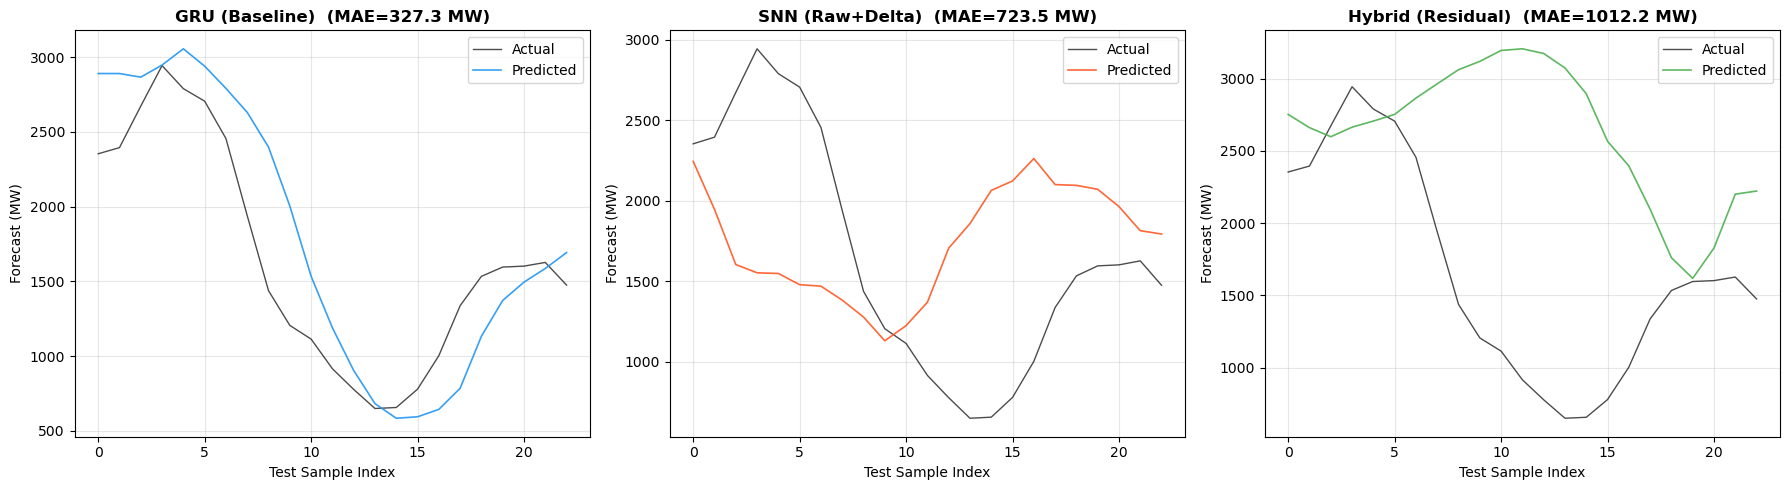

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#2196F3', '#FF5722', '#4CAF50']

for ax, (name, r), c in zip(axes.flat, results.items(), colors):
    t = np.arange(len(r['actuals_mw']))
    ax.plot(t, r['actuals_mw'], 'k-', linewidth=1.0, alpha=0.7, label='Actual')
    ax.plot(t, r['preds_mw'],   color=c, linewidth=1.2, alpha=0.9, label='Predicted')
    ax.set_title(f'{name}  (MAE={r["mae"]:.1f} MW)', fontweight='bold')
    ax.set_xlabel('Test Sample Index')
    ax.set_ylabel('Forecast (MW)')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


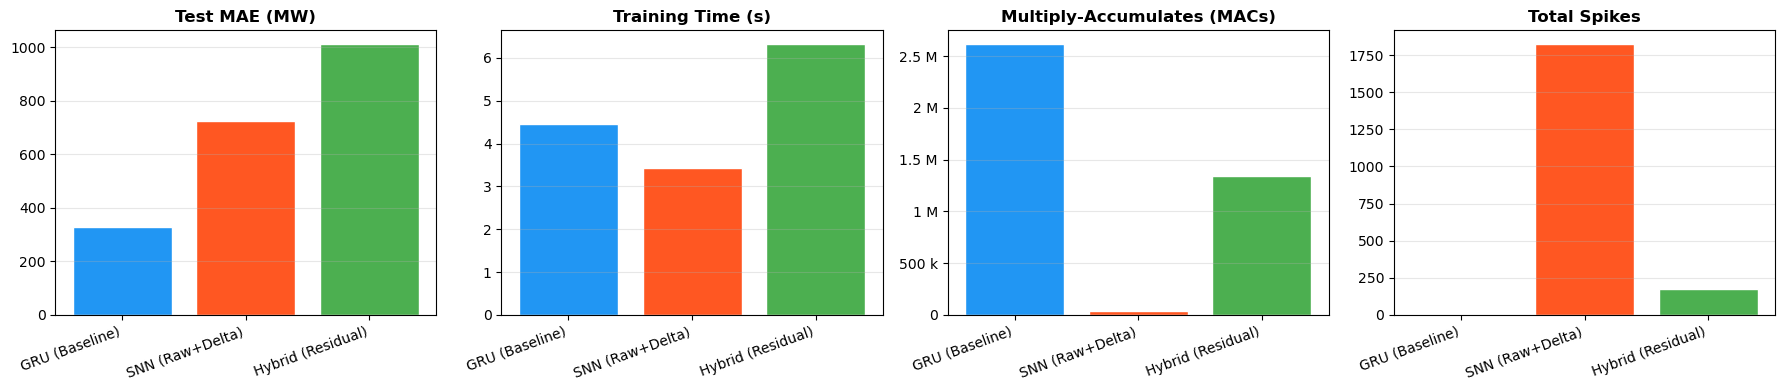

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

names = list(models.keys())

# Test MAE
axes[0].bar(names, [results[n]['mae'] for n in names], color=colors, edgecolor='white')
axes[0].set_title('Test MAE (MW)', fontweight='bold')

# Train Time
axes[1].bar(names, [histories[n]['train_time'] for n in names], color=colors, edgecolor='white')
axes[1].set_title('Training Time (s)', fontweight='bold')

# MACs
axes[2].bar(names, [energy_data[n]['macs'] for n in names], color=colors, edgecolor='white')
axes[2].set_title('Multiply-Accumulates (MACs)', fontweight='bold')
axes[2].yaxis.set_major_formatter(ticker.EngFormatter())

# Spikes
axes[3].bar(names, [energy_data[n]['spikes'] for n in names], color=colors, edgecolor='white')
axes[3].set_title('Total Spikes', fontweight='bold')

for ax in axes:
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=20, ha='right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
print('── Final Summary Table ──')
summary = []
for n in names:
    r, h, e = results[n], histories[n], energy_data[n]
    summary.append({
        'Model': n, 
        'MAE (MW)': f"{r['mae']:.2f}", 
        'RMSE (MW)': f"{r['rmse']:.2f}",
        'MAPE (%)': f"{r['mape']:.2f}",
        'MACs': f"{e['macs']:,}", 
        'Spikes': f"{e['spikes']:,}",
        'Train Time (s)': f"{h['train_time']:.1f}",
        'Best Epoch': h['best_epoch']
    })

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
display(pd.DataFrame(summary).set_index('Model'))


── Final Summary Table ──


,MAE (MW),RMSE (MW),MAPE (%),MACs,Spikes,Train Time (s),Best Epoch
Model,,,,,,,
GRU (Baseline),327.26,409.67,22.44,"2,617,472",0,4.5,24
SNN (Raw+Delta),723.48,858.42,58.37,"40,320","1,825",3.4,14
Hybrid (Residual),1012.25,1330.85,103.71,"1,343,744",172,6.3,32


# Why doesn't SNNs work well (yet) -- Version 2 Update 

We successfully upgraded our SNN from random noise (MAE: 3413 MW) to active continuous learning (MAE: 723 MW) by introducing SNNTorch and membrane potential readouts. However, the GRU baseline still outperforms it (MAE: 327 MW).


## Why the Accuracy Gap Continues to Exists Though it's lesser Now

### A. The Surrogate Gradient Error Accumulation
In a GRU, backpropagation calculates exact gradients using calculus. In our SNN, spike generation (a step function) is mathematically non-differentiable. We bypass this using a "Surrogate Gradient" (specifically, fast_sigmoid).

The Problem: Surrogate gradients are only approximations. When backpropagating through deep LIF cascades over 24 time steps, these tiny approximation errors accumulate wildly. This causes the gradients to become distorted before they reach our input encoders, preventing the network from fine-tuning its weights as precisely as a GRU.
B. Fixed Membrane Leakage (Beta)
Continuous regression requires long-term memory. A GRU uses highly dynamic, learned gating mechanisms to remember things from 24 hours ago.

The Problem: Our snn.Leaky neurons have a fixed decay rate (beta=0.9). This means the neuron physically forgets 10% of its voltage at every time step, regardless of whether that voltage contained important information. It lacks the dynamic "forget gate" native to LSTMs/GRUs.
C. Basic Rate-Encoding Limitation
Currently, we squish the continuous features through a Linear + Sigmoid layer to generate continuous "currents" that induce spiking rates.

The Problem: For extremely precise regression (like predicting 327 MW vs 340 MW), standard rate coding struggles. The network needs an enormous amount of simulation time-steps to generate enough spikes to represent high-precision floats, which we don't have.

2. Advanced Improvements for V5 iterations
Based on the latest 2023/2024 academic literature, here are the most effective strategies to close the accuracy gap in our future iterations:

Strategy 1: Parametric LIF (PLIF) Neurons
Instead of a fixed beta=0.9, we can upgrade to PLIF (Parametric Leaky Integrate-and-Fire) neurons.

How it works: The leak rate (beta) becomes a learnable parameter for every single neuron. Some neurons will learn beta=0.99 to act as long-term memory cells (like a GRU cell state), while others will learn beta=0.5 to act as rapid shock detectors. This dramatically bridges the gap with RNNs.
Strategy 2: Adaptive Surrogate Gradients (AdaLi)
Instead of using a static slope=25 for our surrogate gradient across the whole training cycle, recent SNN papers use adaptive gradients.

How it works: The surrogate gradient starts wide (to allow strong gradient flow and avoid dead neurons) and dynamically "sharpens" to approximate a true spike as training progresses. This drastically reduces gradient error accumulation in deep continuous tasks.
Strategy 3: Temporal Coding (Time-to-First-Spike)
Rather than relying on the number of spikes (Rate Coding), we can use Temporal Coding.

How it works: A high input value causes a neuron to spike immediately (at t=1), while a low value causes it to spike later (at t=15). This allows SNNs to encode high-precision floats perfectly using only a single spike, greatly increasing computational efficiency and regression accuracy.
Strategy 4: A True "Feature Extraction" Hybrid Architecture
Our current residual hybrid forces the GRU and SNN to solve the problem in parallel and adds their results. Literature suggests a different approach is far more stable:

The New Hybrid: Use the SNN strictly as a low-level, high-frequency spatio-temporal feature extractor. Feed the raw data into the SNN. Take the SNN's hidden membrane voltages and feed those complex features directly into the GRU. Let the GRU, which is naturally gifted at continuous math, compute the final continuous output regression.
Summary
The jump from V3 to V4 proved that SNNs can do continuous PJM forecasting. The SNN is currently mimicking a GRU without any of the GRU's dynamic memory advantages. By introducing Learnable Leak Rates (PLIF) and Adaptive Gradients in V5, the SNN will gain the mathematical flexibility of an ANN while preserving the neuromorphic elegance of spikes.